In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import create_folder
plt.style.use('properties.mplstyle')

In [2]:
results_folder = "../results/z_effects/"
create_folder(results_folder)

In [ ]:
L = 256
dim = 3
nc = 8
rho = 1/nc
k = 1.0e-06
NT = 655
P0 = 0.1

path_dir = f"../network/{dim}D_L{L}_nc{nc}_rho{rho:.3f}_k{k:.1e}_Nt{NT}/"
fn = f"network_positions_P0_{P0:.2f}.csv"
df = pd.read_csv(path_dir + fn,sep=',')

def build_counts_by_axis(df: pd.DataFrame) -> pd.DataFrame:
    # Garante que todos os (level, color) existam em cada eixo (inclusive com 0)
    all_colors = sorted(df["color"].unique())

    def _counts(axis_col: str) -> pd.DataFrame:
        levels = sorted(df[axis_col].unique())
        idx = pd.MultiIndex.from_product([levels, all_colors], names=["level", "color"])

        out = (df.groupby([axis_col, "color"])
                 .size()
                 .reindex(idx, fill_value=0)
                 .rename("nc")
                 .reset_index()
              )
        out["axis"] = axis_col  # "x", "y" ou "z"
        return out

    df_counts = pd.concat([_counts("x"), _counts("y"), _counts("z")], ignore_index=True)

    # Se quiser um único nome de coluna para o nível:
    # axis = x/y/z, level = valor do eixo, color = cor, nc = contagem
    df_counts = df_counts[["axis", "level", "color", "nc"]].sort_values(["axis", "level", "color"])

    return df_counts

# --- uso ---
df_counts = build_counts_by_axis(df)

# Salvar (recomendado: parquet; mais rápido e preserva tipos)
df_counts.to_parquet(path_dir + f"counts_by_axis_P0{P0:.2f}.parquet", index=False)

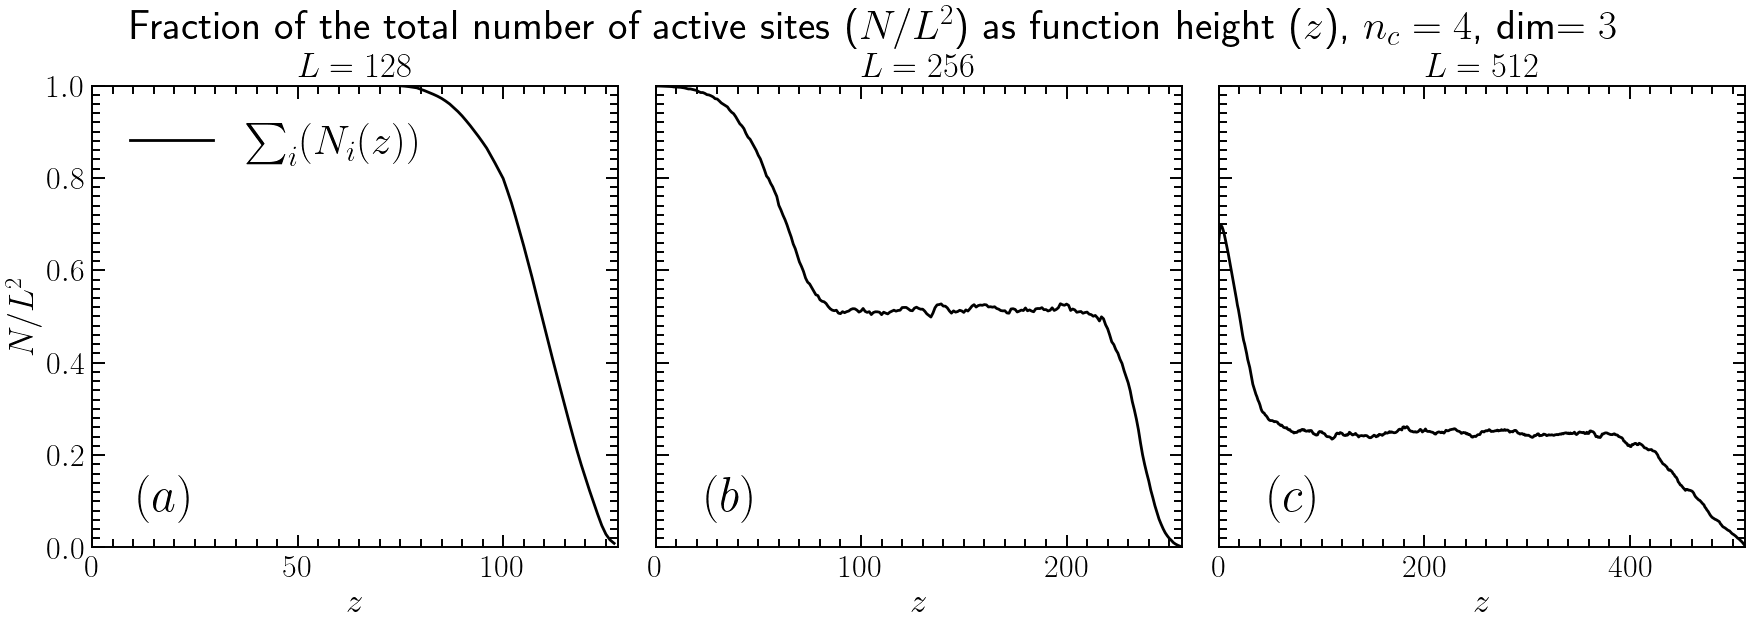

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

dim = 3
nc = 4
rho = 1/nc
k = 1.0e-06
NT = 3000
L_list = [128, 256, 512]
P0 = 0.1

# --- configurações (as suas) ---
colors_used = [
    (0.9, 0.1, 0.1),  # 2 - red
    (1.0, 0.5, 0.0),  # 3 - orange
    (0.1, 0.9, 0.1),  # 4 - green
    (0.1, 0.1, 0.9),  # 5 - blue
    (0.8, 0.2, 0.8),  # 6 - purple
    (0.2, 0.8, 0.8),  # 7 - teal
    (1.0, 1.0, 0.0),  # 8 - yellow
    (0.6, 0.4, 0.2),  # 9 - brown
]

ls = ['solid', 'dotted', 'dashed', 'dashdot',
      (0, (3, 5, 1, 5)), (0, (3, 10, 1, 10)),
      (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

# --- parâmetros plot ---
thickness = 1.4
lw = 2.0
ms = 12
font_tick_size = 23
font_label_size = 25
font_title_size = 30
font_legend_size = 30
colors_index = [2, 3, 4, 5]  # 4 espécies
axis = "z"
n_minor = 10
labels_ref = [r"$(a)$", r"$(b)$", r"$(c)$"]

# --- figura 1x2 ---
fig, axs = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
fig.subplots_adjust(wspace=0.01)  # tente 0.05–0.15

for j, L in enumerate(L_list):
    ax = axs[j]

    path_dir = f"../network/{dim}D_L{L}_nc{nc}_rho{rho:.2f}_k{k:.1e}_Nt{NT}/"
    fn = f"counts_by_axis_P0{P0:.2f}.parquet"
    path_fn = path_dir + fn

    df_counts = pd.read_parquet(path_fn)

    # filtra (axis z + cores desejadas)
    df_sel = df_counts[(df_counts["axis"] == axis) & (df_counts["color"].isin(colors_index))].copy()

    # soma por nível
    df_tot = (df_sel.groupby("level", as_index=False)["nc"]
              .sum()
              .sort_values("level"))

    x = df_tot["level"].to_numpy()
    y = (df_tot["nc"] / (L**2)).to_numpy()

    ax.plot(x, y, color='k', ls=ls[0], ms=ms, mec=colors_used[0], mfc='none', lw=lw,
            label=r'$\sum_i(N_i(z))$')

    # estética
    for spine in ax.spines.values():
        spine.set_linewidth(thickness)

    ax.tick_params(axis='both', which='major', labelsize=font_tick_size,
                   length=9, width=thickness, direction='in',
                   top=True, bottom=True, left=True, right=True)
    ax.tick_params(axis='both', which='minor', labelsize=font_tick_size,
                   length=6, width=thickness, direction='in',
                   top=True, bottom=True, left=True, right=True)

    ax.xaxis.set_minor_locator(AutoMinorLocator(n_minor))
    ax.yaxis.set_minor_locator(AutoMinorLocator(n_minor))

    ax.set_xlim([0, L])
    ax.set_ylim([0, 1.0])
    
    ax.set_xlabel(f'${axis}$', fontsize=font_label_size)
    if j == 0:
        ax.set_ylabel(r'$N/L^2$', fontsize=font_label_size)

#    ax.set_title(f"$L={L}$", fontsize=font_label_size)

    
    # ax.text(0.35, 0.05, f"$L={L}$",
    #         transform=ax.transAxes, ha='right', va='bottom', fontsize=35)
    
    ax.text(0.20, 0.05, labels_ref[j],
            transform=ax.transAxes, ha='right', va='bottom', fontsize=35)
    ax.set_xlim([0, L])
    ax.set_title(f"$L = {L}$", fontsize=font_label_size)
axs[0].legend(fontsize=font_legend_size, loc='upper left')

fig.suptitle(
    f"Fraction of the total number of active sites ($N/L^2$) as function height (${axis}$), "
    f"$n_c={nc}$, dim$=3$",
    fontsize=font_title_size,
    y=0.92
)

plt.tight_layout()
plt.savefig(results_folder + "/cumulative_nc_4.png",
            bbox_inches='tight', pad_inches=0.1)   # <-- evita corte da legenda
plt.show()

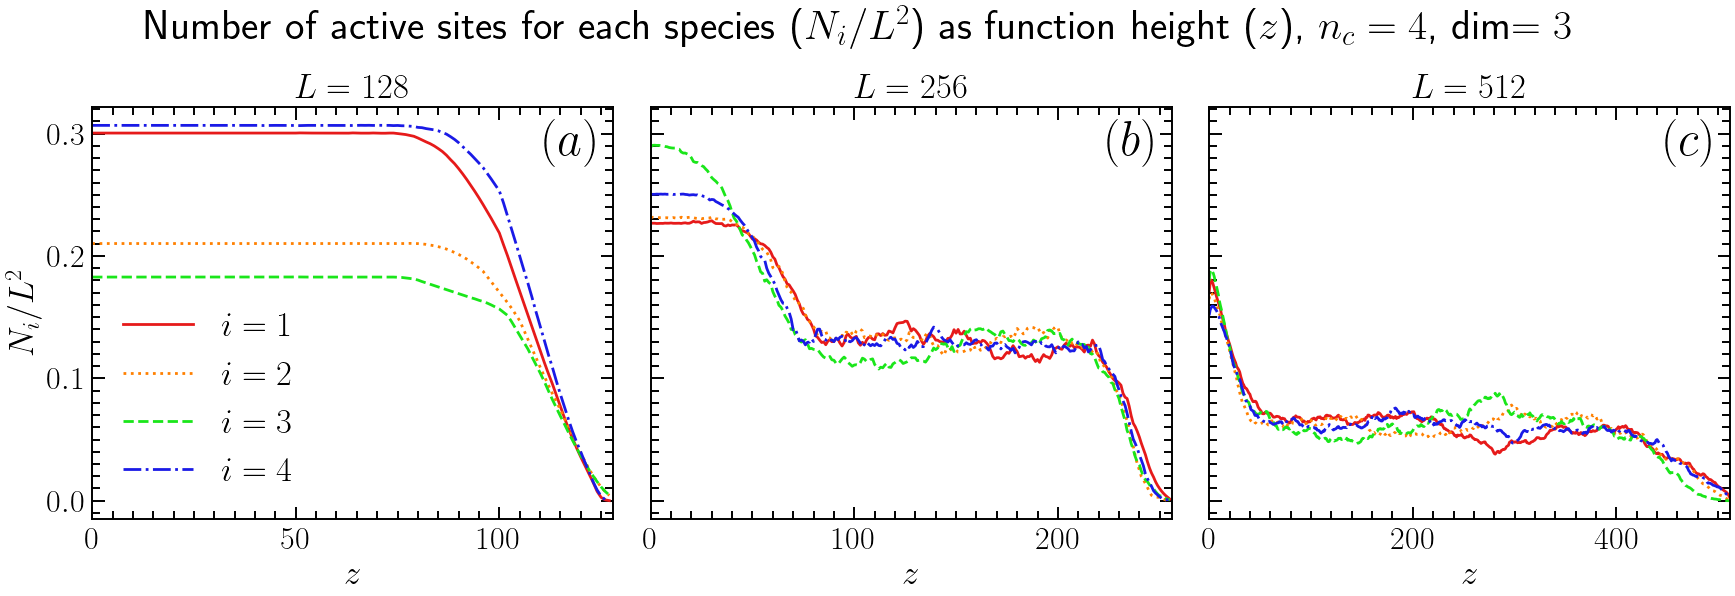

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# --- parâmetros do seu experimento (ajuste conforme seu caminho real) ---
dim = 3
nc = 4
rho = 1/nc
k = 1.0e-06
NT = 3000
L_list = [128, 256, 512]
P0 = 0.1

colors_used = [
    (0.9, 0.1, 0.1),
    (1.0, 0.5, 0.0),
    (0.1, 0.9, 0.1),
    (0.1, 0.1, 0.9),
    (0.8, 0.2, 0.8),
    (0.2, 0.8, 0.8),
    (1.0, 1.0, 0.0),
    (0.6, 0.4, 0.2),
]

ls = ['solid', 'dotted', 'dashed', 'dashdot',
      (0, (3, 5, 1, 5)), (0, (3, 10, 1, 10)),
      (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

# parâmetros plot
thickness = 1.4
lw = 2.0
ms = 12
font_tick_size = 23
font_label_size = 25
font_title_size = 30
font_legend_size = 25
colors_index = [2, 3, 4, 5]  # 4 espécies

n_minor = 10
labels_ref = [r"$(a)$", r"$(b)$", r"$(c)$"]
axis = "z"
n_minor = 10

# --- figura 1x2 ---
fig, axs = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
fig.subplots_adjust(wspace=0.01)  # tente 0.05–0.15

for j, L in enumerate(L_list):
    ax = axs[j]

    # caminho do parquet para cada L
    path_dir = f"../network/{dim}D_L{L}_nc{nc}_rho{rho:.2f}_k{k:.1e}_Nt{NT}/"
    fn = f"counts_by_axis_P0{P0:.2f}.parquet"
    path_fn = path_dir + fn

    df_counts = pd.read_parquet(path_fn)

    df_sel = df_counts[(df_counts["axis"] == axis) & (df_counts["color"].isin(colors_index))].copy()

    # pivot: index=level, colunas=color, valores=nc
    tab = (df_sel.pivot(index="level", columns="color", values="nc")
                  .fillna(0)
                  .sort_index())

    x = tab.index.to_numpy()

    for idx, color in enumerate(colors_index):
        y = (tab[color].to_numpy() / (L**2))
        ax.plot(x, y, label=f'$i = {idx+1}$',
                color=colors_used[idx], ls=ls[idx],
                ms=ms, mec=colors_used[idx], mfc='none', lw=lw)

    for spine in ax.spines.values():
        spine.set_linewidth(thickness)

    ax.tick_params(axis='both', which='major', labelsize=font_tick_size,
                   length=9, width=thickness, direction='in',
                   top=True, bottom=True, left=True, right=True)
    ax.tick_params(axis='both', which='minor', labelsize=font_tick_size,
                   length=6, width=thickness, direction='in',
                   top=True, bottom=True, left=True, right=True)

    ax.xaxis.set_minor_locator(AutoMinorLocator(n_minor))
    ax.yaxis.set_minor_locator(AutoMinorLocator(n_minor))

    ax.set_xlabel(f'${axis}$', fontsize=font_label_size)
    if j == 0:
        ax.set_ylabel(r'$N_i/L^2$', fontsize=font_label_size)

    ax.set_xlim([0, L])

    
    # ax.text(0.25, 0.05, f"$L={L}$",
    #         transform=ax.transAxes, ha='right', va='bottom', fontsize=35)
    
    ax.text(0.98, 0.85, labels_ref[j],
            transform=ax.transAxes, ha='right', va='bottom', fontsize=35)
    ax.set_title(f"$L = {L}$", fontsize=font_label_size)

axs[0].legend(fontsize=font_legend_size)

# título global (suptitle) mais próximo
fig.suptitle(
    f"Number of active sites for each species ($N_i/L^2$) as function height (${axis}$), "
    f"$n_c={nc}$, dim$=3$",
    fontsize=font_title_size,
    y=0.88  # ajuste 0.92–0.98
)

# reserva espaço para o suptitle
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(results_folder + "/Ni_z_nc_4.png",
            bbox_inches='tight', pad_inches=0.1)   # <-- evita corte da legenda
plt.show()


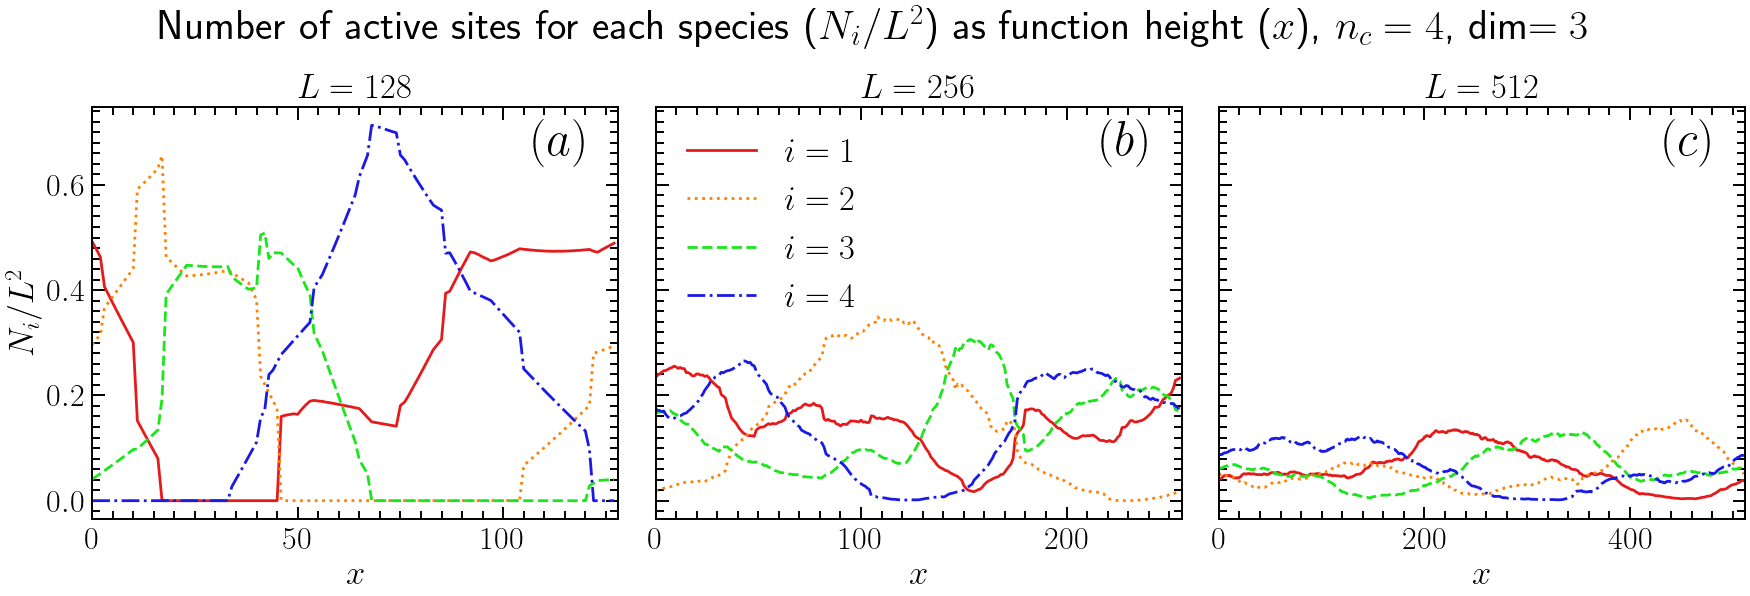

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# --- parâmetros do seu experimento (ajuste conforme seu caminho real) ---
dim = 3
nc = 4
rho = 1/nc
k = 1.0e-06
NT = 3000
L_list = [128, 256, 512]
P0 = 0.1

colors_used = [
    (0.9, 0.1, 0.1),
    (1.0, 0.5, 0.0),
    (0.1, 0.9, 0.1),
    (0.1, 0.1, 0.9),
    (0.8, 0.2, 0.8),
    (0.2, 0.8, 0.8),
    (1.0, 1.0, 0.0),
    (0.6, 0.4, 0.2),
]

ls = ['solid', 'dotted', 'dashed', 'dashdot',
      (0, (3, 5, 1, 5)), (0, (3, 10, 1, 10)),
      (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

# parâmetros plot
thickness = 1.4
lw = 2.0
ms = 12
font_tick_size = 23
font_label_size = 25
font_title_size = 30
font_legend_size = 25
colors_index = [2, 3, 4, 5]  # 4 espécies

n_minor = 10
labels_ref = [r"$(a)$", r"$(b)$", r"$(c)$"]
axis = "x"
n_minor = 10

# --- figura 1x2 ---
fig, axs = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
fig.subplots_adjust(wspace=0.01)  # tente 0.05–0.15

for j, L in enumerate(L_list):
    ax = axs[j]

    # caminho do parquet para cada L
    path_dir = f"../network/{dim}D_L{L}_nc{nc}_rho{rho:.2f}_k{k:.1e}_Nt{NT}/"
    fn = f"counts_by_axis_P0{P0:.2f}.parquet"
    path_fn = path_dir + fn

    df_counts = pd.read_parquet(path_fn)

    df_sel = df_counts[(df_counts["axis"] == axis) & (df_counts["color"].isin(colors_index))].copy()

    # pivot: index=level, colunas=color, valores=nc
    tab = (df_sel.pivot(index="level", columns="color", values="nc")
                  .fillna(0)
                  .sort_index())

    x = tab.index.to_numpy()

    for idx, color in enumerate(colors_index):
        y = (tab[color].to_numpy() / (L**2))
        ax.plot(x, y, label=f'$i = {idx+1}$',
                color=colors_used[idx], ls=ls[idx],
                ms=ms, mec=colors_used[idx], mfc='none', lw=lw)

    for spine in ax.spines.values():
        spine.set_linewidth(thickness)

    ax.tick_params(axis='both', which='major', labelsize=font_tick_size,
                   length=9, width=thickness, direction='in',
                   top=True, bottom=True, left=True, right=True)
    ax.tick_params(axis='both', which='minor', labelsize=font_tick_size,
                   length=6, width=thickness, direction='in',
                   top=True, bottom=True, left=True, right=True)

    ax.xaxis.set_minor_locator(AutoMinorLocator(n_minor))
    ax.yaxis.set_minor_locator(AutoMinorLocator(n_minor))

    ax.set_xlabel(f'${axis}$', fontsize=font_label_size)
    if j == 0:
        ax.set_ylabel(r'$N_i/L^2$', fontsize=font_label_size)

    ax.set_xlim([0, L])

    ax.set_title(f"$L = {L}$", fontsize=font_label_size)
    # ax.text(0.25, 0.05, f"$L={L}$",
    #         transform=ax.transAxes, ha='right', va='bottom', fontsize=35)
    
    ax.text(0.95, 0.85, labels_ref[j],
            transform=ax.transAxes, ha='right', va='bottom', fontsize=35)
    
axs[1].legend(fontsize=font_legend_size, loc='upper left')

# título global (suptitle) mais próximo
fig.suptitle(
    f"Number of active sites for each species ($N_i/L^2$) as function height (${axis}$), "
    f"$n_c={nc}$, dim$=3$",
    fontsize=font_title_size,
    y=0.88  # ajuste 0.92–0.98
)

# reserva espaço para o suptitle
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(results_folder + "/Ni_x_nc_4.png",
            bbox_inches='tight', pad_inches=0.1)   # <-- evita corte da legenda
plt.show()


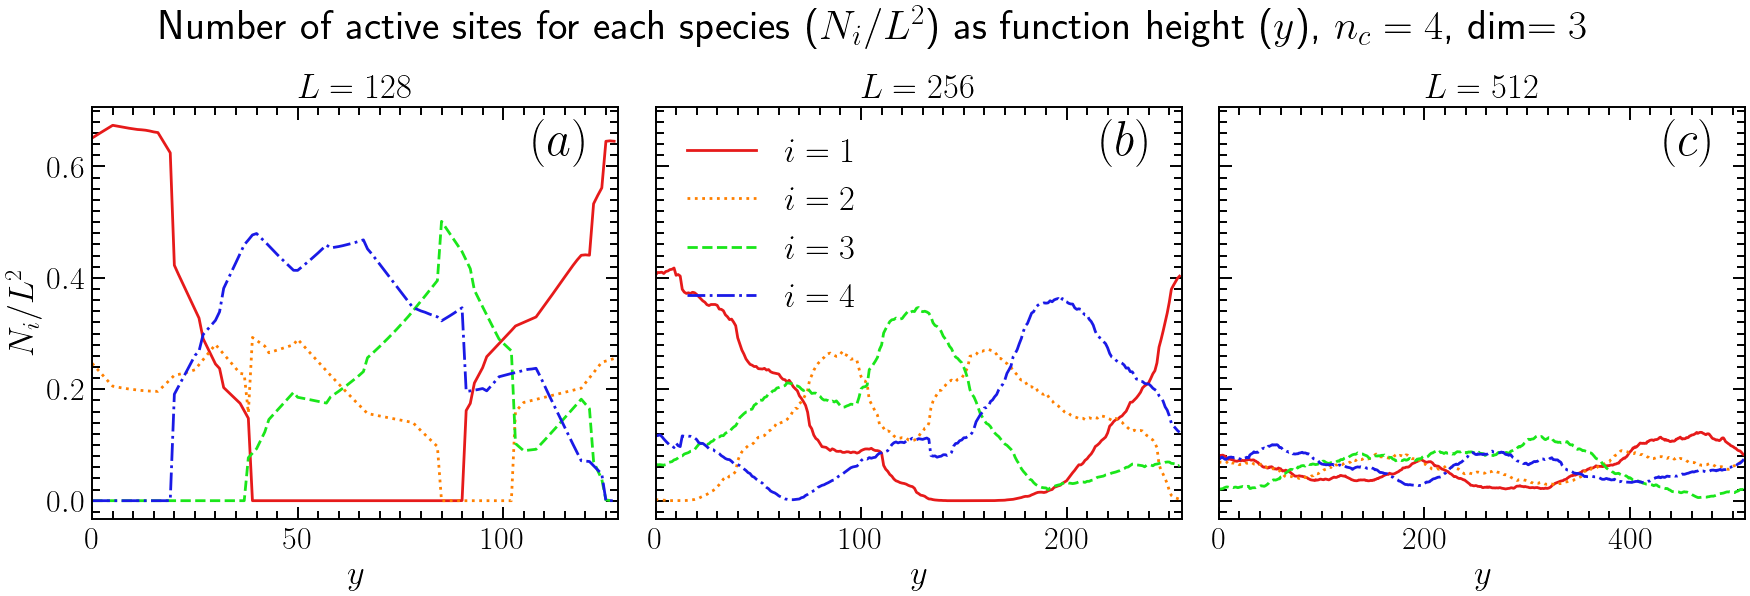

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# --- parâmetros do seu experimento (ajuste conforme seu caminho real) ---
dim = 3
nc = 4
rho = 1/nc
k = 1.0e-06
NT = 3000
L_list = [128, 256, 512]
P0 = 0.1

colors_used = [
    (0.9, 0.1, 0.1),
    (1.0, 0.5, 0.0),
    (0.1, 0.9, 0.1),
    (0.1, 0.1, 0.9),
    (0.8, 0.2, 0.8),
    (0.2, 0.8, 0.8),
    (1.0, 1.0, 0.0),
    (0.6, 0.4, 0.2),
]

ls = ['solid', 'dotted', 'dashed', 'dashdot',
      (0, (3, 5, 1, 5)), (0, (3, 10, 1, 10)),
      (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

# parâmetros plot
thickness = 1.4
lw = 2.0
ms = 12
font_tick_size = 23
font_label_size = 25
font_title_size = 30
font_legend_size = 25
colors_index = [2, 3, 4, 5]  # 4 espécies

n_minor = 10
labels_ref = [r"$(a)$", r"$(b)$", r"$(c)$"]
axis = "y"
n_minor = 10

# --- figura 1x2 ---
fig, axs = plt.subplots(1, 3, figsize=(18, 7), sharey=True)
fig.subplots_adjust(wspace=0.01)  # tente 0.05–0.15

for j, L in enumerate(L_list):
    ax = axs[j]

    # caminho do parquet para cada L
    path_dir = f"../network/{dim}D_L{L}_nc{nc}_rho{rho:.2f}_k{k:.1e}_Nt{NT}/"
    fn = f"counts_by_axis_P0{P0:.2f}.parquet"
    path_fn = path_dir + fn

    df_counts = pd.read_parquet(path_fn)

    df_sel = df_counts[(df_counts["axis"] == axis) & (df_counts["color"].isin(colors_index))].copy()

    # pivot: index=level, colunas=color, valores=nc
    tab = (df_sel.pivot(index="level", columns="color", values="nc")
                  .fillna(0)
                  .sort_index())

    x = tab.index.to_numpy()

    for idx, color in enumerate(colors_index):
        y = (tab[color].to_numpy() / (L**2))
        ax.plot(x, y, label=f'$i = {idx+1}$',
                color=colors_used[idx], ls=ls[idx],
                ms=ms, mec=colors_used[idx], mfc='none', lw=lw)

    for spine in ax.spines.values():
        spine.set_linewidth(thickness)

    ax.tick_params(axis='both', which='major', labelsize=font_tick_size,
                   length=9, width=thickness, direction='in',
                   top=True, bottom=True, left=True, right=True)
    ax.tick_params(axis='both', which='minor', labelsize=font_tick_size,
                   length=6, width=thickness, direction='in',
                   top=True, bottom=True, left=True, right=True)

    ax.xaxis.set_minor_locator(AutoMinorLocator(n_minor))
    ax.yaxis.set_minor_locator(AutoMinorLocator(n_minor))

    ax.set_xlabel(f'${axis}$', fontsize=font_label_size)
    if j == 0:
        ax.set_ylabel(r'$N_i/L^2$', fontsize=font_label_size)

    ax.set_xlim([0, L])

    ax.set_title(f"$L = {L}$", fontsize=font_label_size)
    # ax.text(0.25, 0.05, f"$L={L}$",
    #         transform=ax.transAxes, ha='right', va='bottom', fontsize=35)
    
    ax.text(0.95, 0.85, labels_ref[j],
            transform=ax.transAxes, ha='right', va='bottom', fontsize=35)
    
axs[1].legend(fontsize=font_legend_size, loc='upper left')

# título global (suptitle) mais próximo
fig.suptitle(
    f"Number of active sites for each species ($N_i/L^2$) as function height (${axis}$), "
    f"$n_c={nc}$, dim$=3$",
    fontsize=font_title_size,
    y=0.88  # ajuste 0.92–0.98
)

# reserva espaço para o suptitle
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(results_folder + "/Ni_y_nc_4.png",
            bbox_inches='tight', pad_inches=0.1)   # <-- evita corte da legenda
plt.show()
